In [3]:
# ============================================================
# 1 — Imports & Configuration
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "Data" / "processed" / "project1_train.csv"
VAL_PATH   = PROJECT_ROOT / "Data" / "processed" / "project1_validation.csv"
TEST_PATH  = PROJECT_ROOT / "Data" / "processed" / "project1_test.csv"

train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VAL_PATH)
test = pd.read_csv(TEST_PATH)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (58422, 18)
Validation: (11685, 18)
Test: (11685, 18)


In [4]:
train.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,narrative_group,split
0,2026-04-29T12:51:13.000Z,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt is not yours,I received as phone call from Zenco Collection XXXX trying to collect a debt on a credit card called XXXX XXXX. The ...,NaN,"ZENCO COLLECTION, LLC",IN,47421,NaN,Web,2026-06-15T16:40:23.000Z,Untimely response,No,21704246,1,train
1,2026-04-30T00:19:46.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,On XX/XX/year> I received a notice from XXXX XXXX XXXX that I owed {$660.00} to them for XXXX at an address in Illin...,NaN,"Revco Management, LLC",NV,89074,Servicemember,Web,2026-06-15T18:23:14.000Z,Closed with non-monetary relief,Yes,21731421,2,train
2,2026-04-29T20:05:16.000Z,Debt collection,Credit card debt,Communication tactics,Frequent or repeated calls,MRS BRO sent text messages with my name and debt owed. She is not co-signed on any accounts and they have messaged h...,Company believes it acted appropriately as authorized by contract or law,"MRS BPO, LLC",CA,93257,NaN,Web,2026-06-15T19:50:13.000Z,Closed with non-monetary relief,Yes,21722031,3,train
3,2026-06-15T11:37:15.000Z,Debt collection,I do not know,Took or threatened to take negative or legal action,Threatened or suggested your credit would be damaged,This debt collector has engaged in conduct that violates the Fair Debt Collection Practices Act ( FDCPA ). They are ...,Company has responded to the consumer and the CFPB and chooses not to provide a public response,SYNCHRONY FINANCIAL,TX,75115,NaN,Web,2026-06-15T11:48:11.000Z,Closed with explanation,Yes,23211367,6,train
4,2026-06-15T12:09:07.000Z,Debt collection,I do not know,Took or threatened to take negative or legal action,Threatened or suggested your credit would be damaged,This debt collector has engaged in conduct that violates the Fair Debt Collection Practices Act ( FDCPA ). They are ...,NaN,CL Holdings LLC,TX,75216,NaN,Web,2026-06-15T12:18:43.000Z,Closed with non-monetary relief,Yes,23211835,6,train


In [5]:
# ============================================================
# 2 — Basic Validation
# ============================================================

TARGET = "Product"
TEXT_COL = "Consumer complaint narrative"
DATE_COL = "Date received"
GROUP_COL = "narrative_group"

assert TARGET in train.columns
assert TEXT_COL in train.columns
assert DATE_COL in train.columns
assert GROUP_COL in train.columns

print("Target classes:", train[TARGET].nunique())
print("\nClasses:")
print(sorted(train[TARGET].unique()))

print("\nMissing values in key columns:")
print(
    train[[TARGET, TEXT_COL, DATE_COL, GROUP_COL]]
    .isna()
    .sum()
)

Target classes: 11

Classes:
['Checking or savings account', 'Credit card', 'Credit reporting or other personal consumer reports', 'Debt collection', 'Debt or credit management', 'Money transfer, virtual currency, or money service', 'Mortgage', 'Payday loan, title loan, personal loan, or advance loan', 'Prepaid card', 'Student loan', 'Vehicle loan or lease']

Missing values in key columns:
Product                         0
Consumer complaint narrative    0
Date received                   0
narrative_group                 0
dtype: int64


In [6]:
# ============================================================
# 3 — Verify Group Leakage
# ============================================================

train_groups = set(train[GROUP_COL])
val_groups = set(validation[GROUP_COL])
test_groups = set(test[GROUP_COL])

print("Train ∩ Validation:", len(train_groups & val_groups))
print("Train ∩ Test:", len(train_groups & test_groups))
print("Validation ∩ Test:", len(val_groups & test_groups))

assert len(train_groups & val_groups) == 0
assert len(train_groups & test_groups) == 0
assert len(val_groups & test_groups) == 0

print("\nGroup leakage check: PASS")

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Group leakage check: PASS


#### 1. Product distribution

In [7]:
# ============================================================
# 4 — Target Distribution
# ============================================================

product_counts = (
    train[TARGET]
    .value_counts()
    .rename("count")
    .to_frame()
)

product_counts["percentage"] = (
    product_counts["count"] / len(train) * 100
).round(2)

product_counts

,count,percentage
Product,,
Debt collection,19236,32.93
Checking or savings account,10480,17.94
Credit card,9853,16.87
"Money transfer, virtual currency, or money service",4675,8.00
Mortgage,3811,6.52
Vehicle loan or lease,2840,4.86
Credit reporting or other personal consumer reports,2382,4.08
"Payday loan, title loan, personal loan, or advance loan",2063,3.53
Student loan,1917,3.28


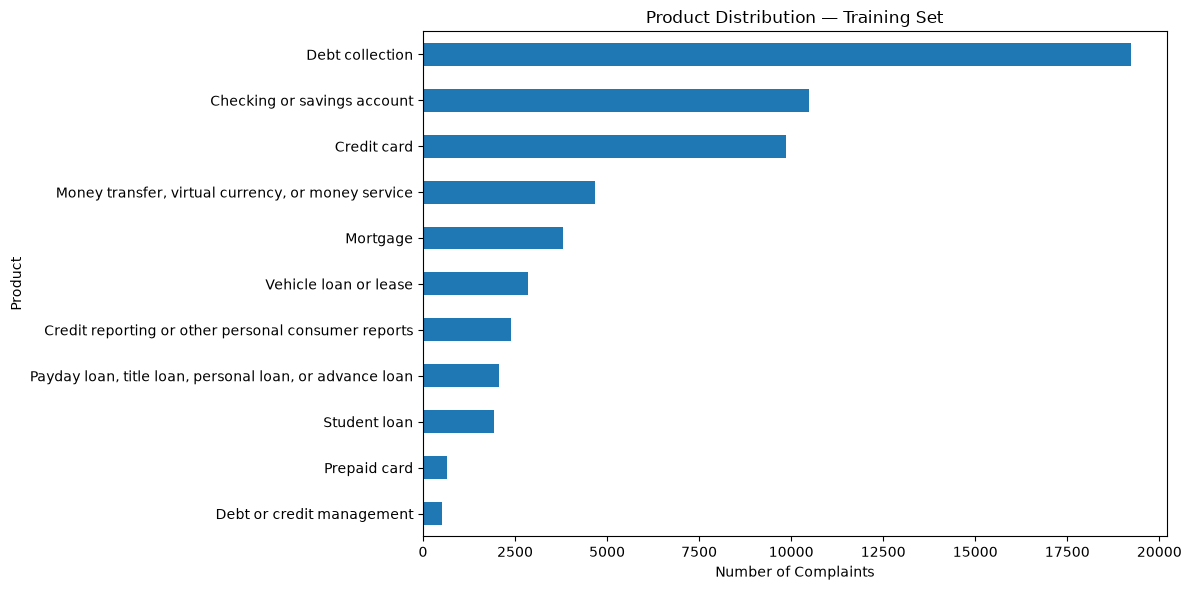

In [8]:
# ============================================================
# 5 — Product Distribution Plot
# ============================================================

plt.figure(figsize=(12, 6))

product_counts["count"].sort_values().plot(kind="barh")

plt.title("Product Distribution — Training Set")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### 2. Narrative length evidence

In [9]:
# ============================================================
# 6 — Narrative Length Features
# ============================================================

train = train.copy()

train["narrative_chars"] = train[TEXT_COL].str.len()

train["narrative_words"] = (
    train[TEXT_COL]
    .str.split()
    .str.len()
)

train["narrative_sentences"] = (
    train[TEXT_COL]
    .str.count(r"[.!?]")
)

train[
    [
        "narrative_chars",
        "narrative_words",
        "narrative_sentences"
    ]
].describe()

,narrative_chars,narrative_words,narrative_sentences
count,58422.000000,58422.000000,58422.000000
mean,1386.954315,229.002807,13.258635
std,1422.601750,228.130843,13.741482
min,42.000000,5.000000,0.000000
25%,530.000000,93.000000,6.000000
50%,1041.000000,175.000000,10.000000
75%,1787.000000,292.000000,17.000000
max,32031.000000,5347.000000,413.000000


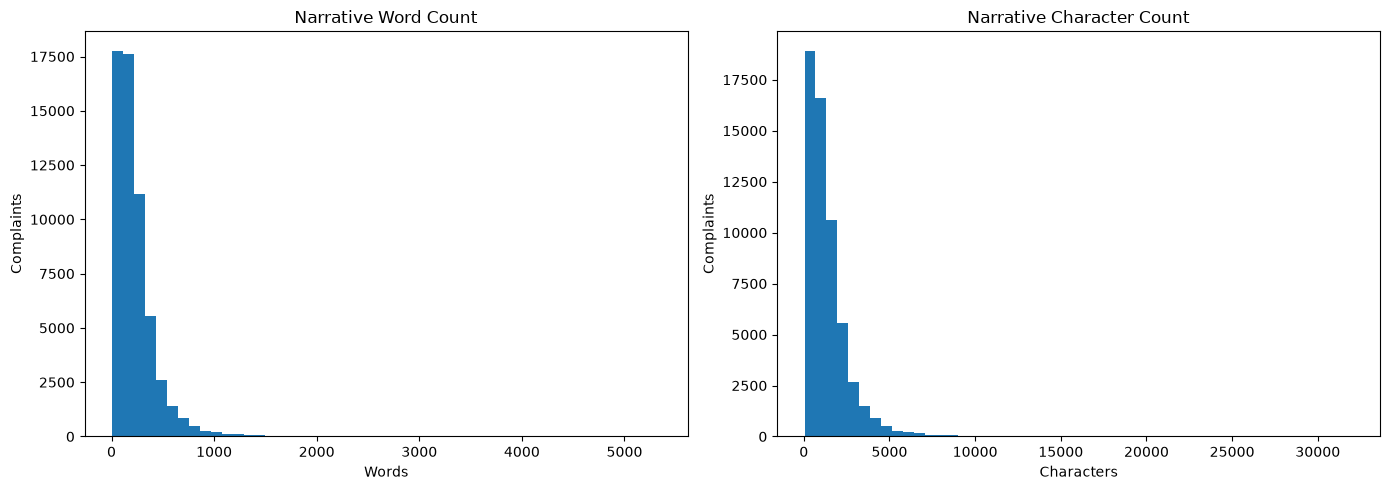

In [10]:
# ============================================================
# 7 — Narrative Length Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    train["narrative_words"],
    bins=50
)

axes[0].set_title("Narrative Word Count")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Complaints")

axes[1].hist(
    train["narrative_chars"],
    bins=50
)

axes[1].set_title("Narrative Character Count")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Complaints")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 8 — Narrative Length by Product
# ============================================================

length_by_product = (
    train.groupby(TARGET)["narrative_words"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .sort_values("median", ascending=False)
)

length_by_product.round(2)

,count,mean,median,min,max
Product,,,,,
Mortgage,3811,331.02,249.0,10,4017
Vehicle loan or lease,2840,269.25,220.0,8,4997
Credit card,9853,260.46,216.0,6,4950
Student loan,1917,258.35,211.0,8,4994
Checking or savings account,10480,244.38,193.0,7,5347
"Money transfer, virtual currency, or money service",4675,239.82,193.0,9,3916
"Payday loan, title loan, personal loan, or advance loan",2063,230.84,187.0,8,2130
Prepaid card,652,201.75,158.0,8,1177
Debt or credit management,513,214.75,138.0,8,4643


<Figure size 1400x700 with 0 Axes>

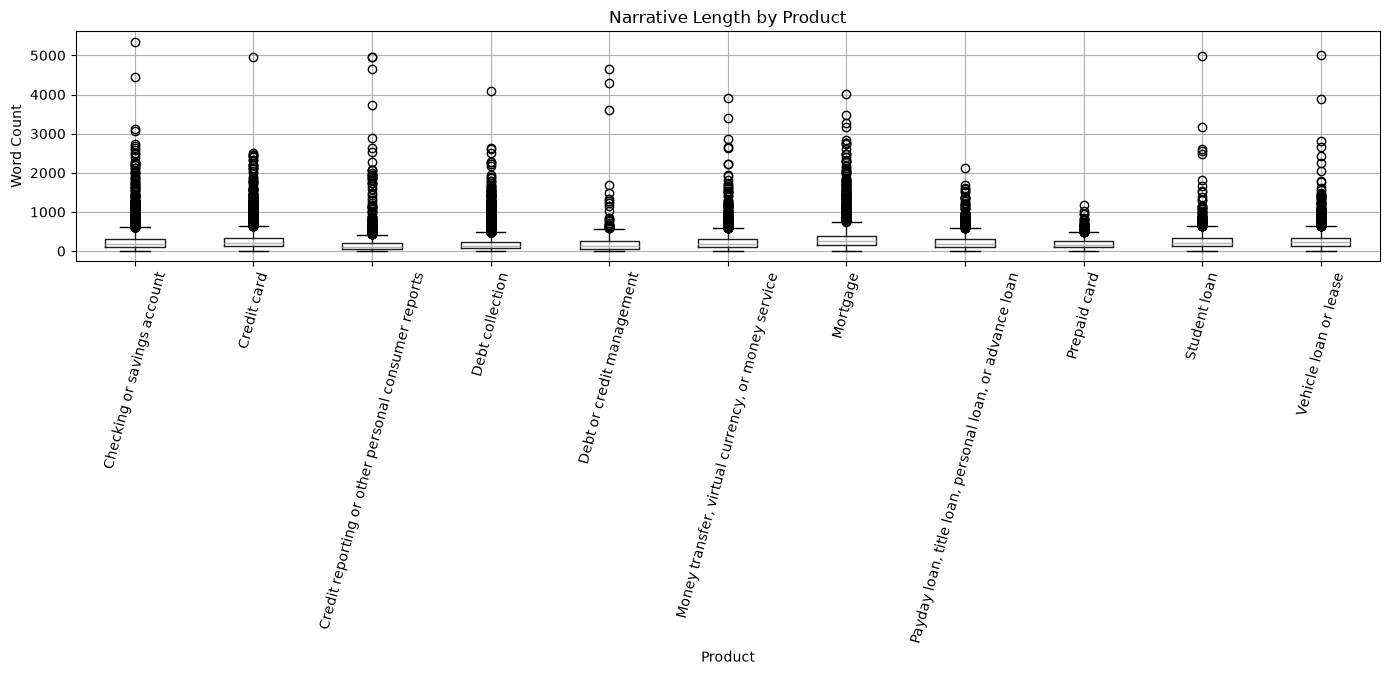

In [12]:
# ============================================================
# 9 — Boxplot: Narrative Length by Product
# ============================================================

plt.figure(figsize=(14, 7))

train.boxplot(
    column="narrative_words",
    by=TARGET,
    rot=75,
    figsize=(14, 7)
)

plt.title("Narrative Length by Product")
plt.suptitle("")
plt.xlabel("Product")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()

### 3. Duplicate/template concentration

In [13]:
# ============================================================
# 10 — Duplicate Concentration
# ============================================================

duplicate_stats = (
    train.groupby(GROUP_COL)
    .agg(
        rows=(GROUP_COL, "size"),
        product_count=(TARGET, "nunique")
    )
)

duplicate_stats["is_duplicate"] = duplicate_stats["rows"] > 1

print("Unique narrative groups:", len(duplicate_stats))
print(
    "Duplicate groups:",
    duplicate_stats["is_duplicate"].sum()
)

print(
    "Rows belonging to duplicate groups:",
    duplicate_stats.loc[
        duplicate_stats["is_duplicate"],
        "rows"
    ].sum()
)

Unique narrative groups: 52966
Duplicate groups: 880
Rows belonging to duplicate groups: 6336


In [14]:
# ============================================================
# 11 — Duplicate Concentration by Product
# ============================================================

train["is_duplicate_narrative"] = (
    train.groupby(GROUP_COL)[GROUP_COL]
    .transform("size")
    .gt(1)
)

duplicate_by_product = (
    train.groupby(TARGET)
    .agg(
        total_rows=(TARGET, "size"),
        duplicate_rows=("is_duplicate_narrative", "sum")
    )
)

duplicate_by_product["duplicate_percentage"] = (
    duplicate_by_product["duplicate_rows"]
    / duplicate_by_product["total_rows"]
    * 100
)

duplicate_by_product.sort_values(
    "duplicate_percentage",
    ascending=False
).round(2)

,total_rows,duplicate_rows,duplicate_percentage
Product,,,
Credit reporting or other personal consumer reports,2382,1392,58.44
Debt collection,19236,4776,24.83
Credit card,9853,118,1.20
Debt or credit management,513,4,0.78
Vehicle loan or lease,2840,15,0.53
"Money transfer, virtual currency, or money service",4675,15,0.32
Checking or savings account,10480,12,0.11
Student loan,1917,2,0.10
"Payday loan, title loan, personal loan, or advance loan",2063,2,0.10


### 4. Temporal product drift

In [15]:
# ============================================================
# 12 — Monthly Product Distribution
# ============================================================

train["date_received"] = pd.to_datetime(
    train[DATE_COL],
    errors="coerce",
    utc=True
)

train["received_month"] = (
    train["date_received"]
    .dt.to_period("M")
    .astype(str)
)

monthly_product = pd.crosstab(
    train["received_month"],
    train[TARGET],
    normalize="index"
) * 100

monthly_product.round(2)

C:\Users\MY PC\AppData\Local\Temp\ipykernel_13736\3950353842.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


Product,Checking or savings account,Credit card,Credit reporting or other personal consumer reports,Debt collection,Debt or credit management,"Money transfer, virtual currency, or money service",Mortgage,"Payday loan, title loan, personal loan, or advance loan",Prepaid card,Student loan,Vehicle loan or lease
received_month,,,,,,,,,,,
2026-03,15.86,15.36,3.80,38.50,0.92,7.96,5.80,3.06,0.97,3.16,4.62
2026-04,17.99,17.24,3.78,31.38,0.92,8.49,6.73,3.71,1.02,3.65,5.09
2026-05,17.71,17.54,3.89,32.04,0.85,8.14,6.66,3.75,1.12,3.35,4.96
2026-06,19.33,16.82,4.60,30.38,0.82,8.07,6.77,3.74,1.41,3.36,4.70
2026-07,22.85,19.63,5.37,26.72,0.82,5.53,7.55,3.41,1.15,1.83,5.15
2026-08,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


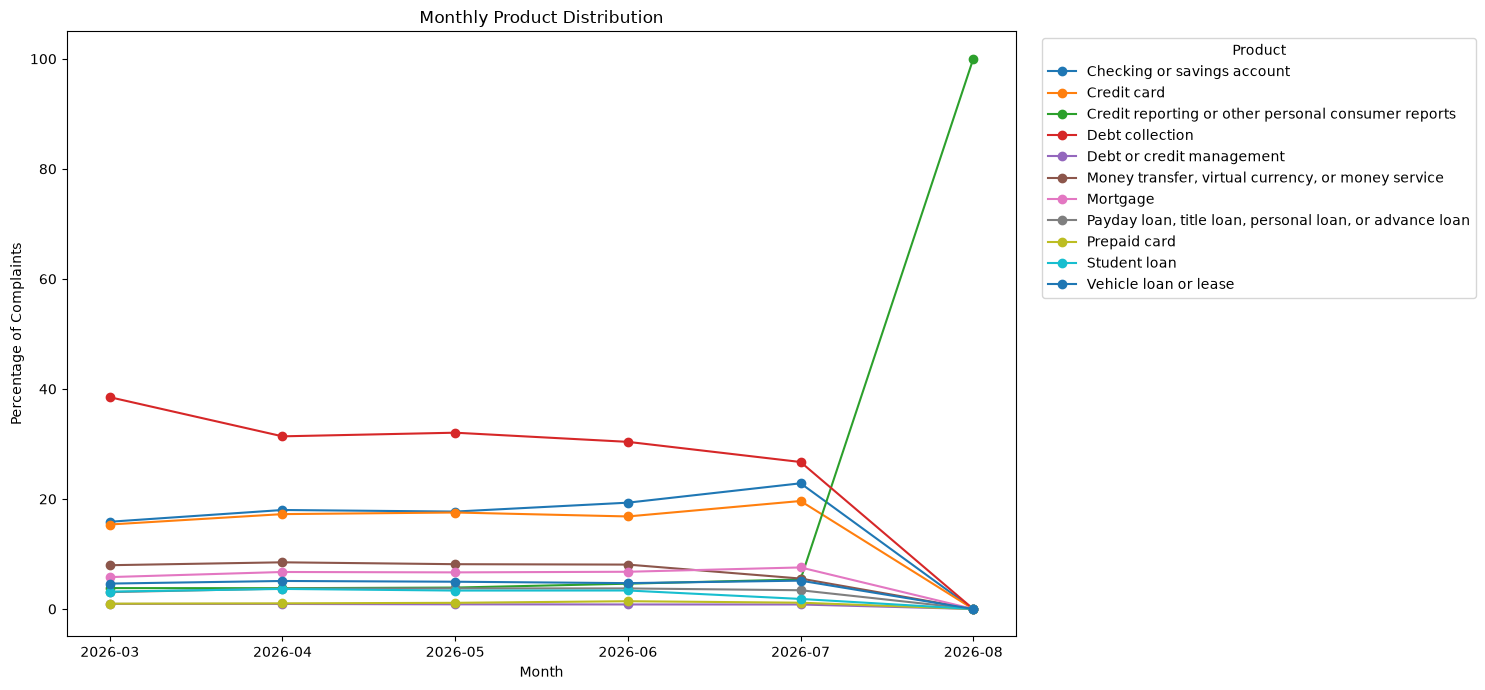

In [16]:
# ============================================================
# 13 — Temporal Distribution Plot
# ============================================================

monthly_product.plot(
    figsize=(15, 7),
    marker="o"
)

plt.title("Monthly Product Distribution")
plt.xlabel("Month")
plt.ylabel("Percentage of Complaints")
plt.legend(
    title="Product",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 5. Representative complaint examples

- This helps us understand whether the narrative itself contains enough semantic information to predict Product.

In [23]:
len(train.columns.tolist())

24

In [27]:
# ============================================================
# 14 — Representative Narratives
# ============================================================

sample_per_product = pd.concat(
    [
        group.sample(
            n=min(3, len(group)),
            random_state=42
        )
        for _, group in train.groupby(TARGET)
    ],
    ignore_index=True
)

for product, group in sample_per_product.groupby(TARGET):

    print("\n" + "=" * 100)
    print(product)
    print("=" * 100)

    for i, text in enumerate(
        group[TEXT_COL],
        start=1
    ):
        print(f"\nExample {i}:")
        print(text[:1000])


Checking or savings account

Example 1:
I deposited a check in person to navy federal credit union on XX/XX/XXXX. The funds was cleared on the XXXX of XXXX but was held. According to navy federal credit union when they called to verify the check they was told it was invalid and fraud. However after they was told this the CFO of the issuing bank called navy federal and wrote them a letter stating the check was valid and that the funds have cleared there bank account. Navy federal said that letter wasnt good enough and asked for a hold harmless letter. That was submitted on XX/XX/XXXX Ive spoke with navy federal several times and no one can give me a timeline on when the funds will be released. All Im hearing is we review letters in the order they was received.

Example 2:
I am submitting this complaint regarding the unexpected closure of my bank account with Chase. I used my account in good faith to manage my finances and recently made a rent payment through XXXX, which initially proce

In [28]:
print(sample_per_product.columns.tolist())

['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID', 'narrative_group', 'split', 'narrative_chars', 'narrative_words', 'narrative_sentences', 'is_duplicate_narrative', 'date_received', 'received_month']


### 6. Very simple text signal investigation

- Only checking whether classes have obvious vocabulary differences.

In [29]:
# ============================================================
# 15 — Common Words by Product
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    min_df=5,
    max_features=10000,
    ngram_range=(1, 2)
)

X_counts = vectorizer.fit_transform(
    train[TEXT_COL]
)

terms = np.array(vectorizer.get_feature_names_out())

print("Vocabulary size:", len(terms))
print("Matrix shape:", X_counts.shape)

Vocabulary size: 10000
Matrix shape: (58422, 10000)


In [32]:
# ============================================================
# 16 — Top Terms for Each Product
# ============================================================

from collections import defaultdict

term_scores = {}

for product in train[TARGET].unique():

    mask = train[TARGET].values == product

    class_counts = np.asarray(
        X_counts[mask].sum(axis=0)
    ).ravel()

    total_counts = class_counts.sum()

    top_indices = np.argsort(
        class_counts
    )[-15:][::-1]

    term_scores[product] = [
        (terms[i], int(class_counts[i]))
        for i in top_indices
    ]

for product, terms_list in term_scores.items():

    print("\n", "=" * 70)
    print(product)
    print("=" * 70)

    print(terms_list)


Debt collection
[('xxxx', 149213), ('xxxx xxxx', 77555), ('debt', 51561), ('account', 44824), ('credit', 39015), ('xx', 30650), ('reporting', 28256), ('collection', 24719), ('information', 17798), ('report', 15987), ('xx xx', 15142), ('validation', 15036), ('documentation', 13225), ('original', 12087), ('provide', 11975)]

Credit card
[('xxxx', 114640), ('xxxx xxxx', 45430), ('xx', 41344), ('account', 24292), ('credit', 22362), ('xx xx', 20527), ('00', 18213), ('card', 17799), ('xx xxxx', 12550), ('payment', 10088), ('bank', 9634), ('dispute', 9343), ('year', 7970), ('credit card', 7781), ('balance', 7332)]

Money transfer, virtual currency, or money service
[('xxxx', 55263), ('xxxx xxxx', 23182), ('xx', 15766), ('account', 13444), ('xx xx', 7814), ('00', 7689), ('funds', 5690), ('bank', 5066), ('paypal', 4721), ('app', 4562), ('cash', 4482), ('money', 4369), ('transaction', 4367), ('xx xxxx', 3930), ('cash app', 3923)]

Vehicle loan or lease
[('xxxx', 33937), ('xxxx xxxx', 14273), ('

### 7. Feature hypothesis table

- Don't automatically engineer every possible feature.

In [33]:
# ============================================================
# 17 — Feature Hypothesis Register
# ============================================================

feature_hypotheses = pd.DataFrame([
    {
        "feature": "Consumer complaint narrative",
        "type": "Text",
        "available_at_prediction": "Yes",
        "evidence": "Primary semantic information",
        "risk": "Low",
        "decision": "KEEP"
    },
    {
        "feature": "Narrative word count",
        "type": "Numerical",
        "available_at_prediction": "Yes",
        "evidence": "May capture complaint complexity/detail",
        "risk": "Low",
        "decision": "INVESTIGATE"
    },
    {
        "feature": "Narrative character count",
        "type": "Numerical",
        "available_at_prediction": "Yes",
        "evidence": "Proxy for text length",
        "risk": "Low",
        "decision": "INVESTIGATE"
    },
    {
        "feature": "Date received",
        "type": "Datetime",
        "available_at_prediction": "Yes",
        "evidence": "Potential temporal distribution differences",
        "risk": "Medium",
        "decision": "SECONDARY MODEL"
    },
    {
        "feature": "Company",
        "type": "Categorical",
        "available_at_prediction": "Yes",
        "evidence": "May contain product-specific operational patterns",
        "risk": "Medium",
        "decision": "SECONDARY MODEL"
    },
    {
        "feature": "State",
        "type": "Categorical",
        "available_at_prediction": "Yes",
        "evidence": "Potential geographic signal",
        "risk": "Medium",
        "decision": "SECONDARY MODEL"
    },
    {
        "feature": "ZIP code",
        "type": "Categorical",
        "available_at_prediction": "Yes",
        "evidence": "Potential geographic signal",
        "risk": "High",
        "decision": "INVESTIGATE"
    },
    {
        "feature": "Sub-product",
        "type": "Categorical",
        "available_at_prediction": "Downstream",
        "evidence": "Child taxonomy of Product",
        "risk": "Very High",
        "decision": "REJECT"
    },
    {
        "feature": "Issue",
        "type": "Categorical",
        "available_at_prediction": "Downstream",
        "evidence": "Taxonomy descendant",
        "risk": "Very High",
        "decision": "REJECT"
    },
    {
        "feature": "Sub-issue",
        "type": "Categorical",
        "available_at_prediction": "Downstream",
        "evidence": "Taxonomy descendant",
        "risk": "Very High",
        "decision": "REJECT"
    }
])

feature_hypotheses

,feature,type,available_at_prediction,evidence,risk,decision
0,Consumer complaint narrative,Text,Yes,Primary semantic information,Low,KEEP
1,Narrative word count,Numerical,Yes,May capture complaint complexity/detail,Low,INVESTIGATE
2,Narrative character count,Numerical,Yes,Proxy for text length,Low,INVESTIGATE
3,Date received,Datetime,Yes,Potential temporal distribution differences,Medium,SECONDARY MODEL
4,Company,Categorical,Yes,May contain product-specific operational patterns,Medium,SECONDARY MODEL
5,State,Categorical,Yes,Potential geographic signal,Medium,SECONDARY MODEL
6,ZIP code,Categorical,Yes,Potential geographic signal,High,INVESTIGATE
7,Sub-product,Categorical,Downstream,Child taxonomy of Product,Very High,REJECT
8,Issue,Categorical,Downstream,Taxonomy descendant,Very High,REJECT
9,Sub-issue,Categorical,Downstream,Taxonomy descendant,Very High,REJECT


### Evidence Summary

#### PROJECT 1 — FEATURE EVIDENCE ANALYSIS
=====================================

Completed:
- ✓ Target distribution
- ✓ Narrative length analysis
- ✓ Narrative length by Product
- ✓ Duplicate concentration
- ✓ Temporal Product distribution
- ✓ Representative narrative inspection
- ✓ Vocabulary inspection
- ✓ Feature hypothesis register
